# Reginald – Comparison and Error Analysis

**Task:** Compare baseline vs improved model results, identify common failure cases, and prepare final tables, charts and visuals for the report and presentation.

**Inputs:**
- `outputs/saikiran/metrics_summary.csv` — baseline metrics (val + test)
- `outputs/saikiran/prediction_masks/` — baseline prediction PNGs per sample
- `outputs/divya/comparison_summary.csv` — baseline vs improved comparison
- `outputs/divya/training_log.csv` — improved model training log
- `outputs/prajwal/training_log.csv` — baseline training log
- `data/processed/metadata.csv` — for loading test images and GT masks

**Outputs:**
- `outputs/reginald/final_comparison_table.csv`
- `outputs/reginald/final_comparison_chart.png`
- `outputs/reginald/training_curves_comparison.png`
- `outputs/reginald/per_sample_metrics.csv`
- `outputs/reginald/failure_analysis/category_counts.png`
- `outputs/reginald/failure_analysis/score_distributions.png`
- `outputs/reginald/failure_analysis/worst_cases.png`
- `outputs/reginald/failure_analysis/summary.md`

## 1. Imports and Project Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

import rasterio
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    jaccard_score, accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

# ── Project root ───────────────────────────────────────────────────
def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "src").exists():
            return p
    for p in [start, *start.parents]:
        if (p / "README.md").exists():
            return p
    return start

PROJECT_ROOT = find_project_root()

# Input paths
METADATA_PATH      = PROJECT_ROOT / "data" / "processed" / "metadata.csv"
SAIKIRAN_METRICS   = PROJECT_ROOT / "outputs" / "saikiran" / "metrics_summary.csv"
PREDICTIONS_DIR    = PROJECT_ROOT / "outputs" / "saikiran" / "prediction_masks"
DIVYA_COMPARISON   = PROJECT_ROOT / "outputs" / "divya" / "comparison_summary.csv"
PRAJWAL_LOG        = PROJECT_ROOT / "outputs" / "prajwal" / "training_log.csv"
DIVYA_LOG          = PROJECT_ROOT / "outputs" / "divya" / "training_log.csv"

# Output paths
OUT_DIR            = PROJECT_ROOT / "outputs" / "reginald"
FAILURE_DIR        = OUT_DIR / "failure_analysis"
WORST_DIR          = FAILURE_DIR / "worst_cases"

for d in [ FAILURE_DIR, WORST_DIR]:
    d.mkdir(parents=True, exist_ok=True)


print("Saikiran metrics  :", SAIKIRAN_METRICS.exists())
print("Divya comparison  :", DIVYA_COMPARISON.exists())
print("Predictions dir   :", PREDICTIONS_DIR.exists())
print("Prajwal log       :", PRAJWAL_LOG.exists())
print("Divya log         :", DIVYA_LOG.exists())

Saikiran metrics  : True
Divya comparison  : True
Predictions dir   : True
Prajwal log       : True
Divya log         : True


## 2. Load All Results

In [2]:
# ── Baseline metrics (from Saikiran) ──────────────────────────────
saikiran_df = pd.read_csv(SAIKIRAN_METRICS)
print("Saikiran metrics:")
print(saikiran_df.to_string(index=False))

baseline_val  = dict(zip(saikiran_df["Metric"], saikiran_df["Validation"]))
baseline_test = dict(zip(saikiran_df["Metric"], saikiran_df["Test"]))

# ── Improved model metrics (from Divya) ───────────────────────────
divya_df = pd.read_csv(DIVYA_COMPARISON)
print("\nDivya comparison:")
print(divya_df.to_string(index=False))

improved_val = dict(zip(divya_df["Metric"], divya_df["Improved (Val)"]))

# ── Training logs ─────────────────────────────────────────────────
prajwal_log = pd.read_csv(PRAJWAL_LOG)
divya_log   = pd.read_csv(DIVYA_LOG)

print(f"\nBaseline training epochs: {len(prajwal_log)}")
print(f"Improved training epochs: {len(divya_log)}")

Saikiran metrics:
   Metric  Validation   Test
      IoU      0.3258 0.3138
  Dice/F1      0.4915 0.4777
Precision      0.3842 0.3867
   Recall      0.6818 0.6246
 Accuracy      0.9825 0.9740

Divya comparison:
   Metric  Baseline (Val)  Improved (Val)  Change Improved?
      IoU          0.3258          0.3123 -0.0135         ✗
  Dice/F1          0.4915          0.4759 -0.0156         ✗
Precision          0.3842          0.3579 -0.0263         ✗
   Recall          0.6818          0.7101  0.0283         ✓
 Accuracy          0.9825          0.9806 -0.0019         ✗

Baseline training epochs: 30
Improved training epochs: 30


## 3. Final Comparison Table

In [3]:
metrics_list = ["IoU", "Dice/F1", "Precision", "Recall", "Accuracy"]

final_table = pd.DataFrame({
    "Metric"                    : metrics_list,
    "Baseline – Val"            : [baseline_val.get(m, 0)  for m in metrics_list],
    "Baseline – Test"           : [baseline_test.get(m, 0) for m in metrics_list],
    "Attention U-Net – Val"     : [improved_val.get(m, 0)  for m in metrics_list],
    "Change (Val)"              : [round(improved_val.get(m,0) - baseline_val.get(m,0), 4) for m in metrics_list],
})

final_table["Improved?"] = final_table["Change (Val)"].apply(
    lambda x: "✓ Yes" if x > 0 else ("– Neutral" if x == 0 else "✗ No")
)

print("=" * 75)
print("FINAL COMPARISON TABLE – BASELINE vs ATTENTION U-NET")
print("=" * 75)
print(final_table.to_string(index=False))

final_table.to_csv(OUT_DIR / "final_comparison_table.csv", index=False)
print("\nSaved:", "final_comparison_table.csv")

FINAL COMPARISON TABLE – BASELINE vs ATTENTION U-NET
   Metric  Baseline – Val  Baseline – Test  Attention U-Net – Val  Change (Val) Improved?
      IoU          0.3258           0.3138                 0.3123       -0.0135      ✗ No
  Dice/F1          0.4915           0.4777                 0.4759       -0.0156      ✗ No
Precision          0.3842           0.3867                 0.3579       -0.0263      ✗ No
   Recall          0.6818           0.6246                 0.7101        0.0283     ✓ Yes
 Accuracy          0.9825           0.9740                 0.9806       -0.0019      ✗ No

Saved: final_comparison_table.csv


## 4. Final Comparison Chart

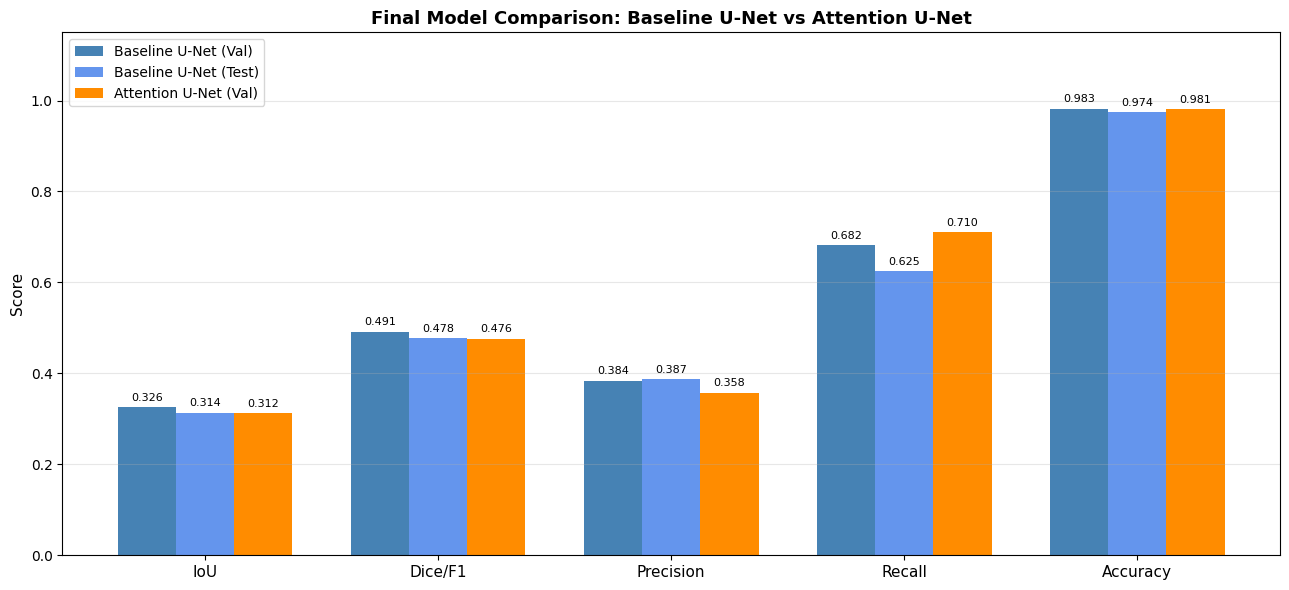

Saved: final_comparison_chart.png


In [4]:
x     = np.arange(len(metrics_list))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

b1 = ax.bar(x - width,     final_table["Baseline – Val"],        width, label="Baseline U-Net (Val)",        color="steelblue")
b2 = ax.bar(x,             final_table["Baseline – Test"],       width, label="Baseline U-Net (Test)",       color="cornflowerblue")
b3 = ax.bar(x + width,     final_table["Attention U-Net – Val"], width, label="Attention U-Net (Val)",       color="darkorange")

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Final Model Comparison: Baseline U-Net vs Attention U-Net", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "final_comparison_chart.png", dpi=150)
plt.show()
print("Saved:","final_comparison_chart.png")

## 5. Training Curves Comparison

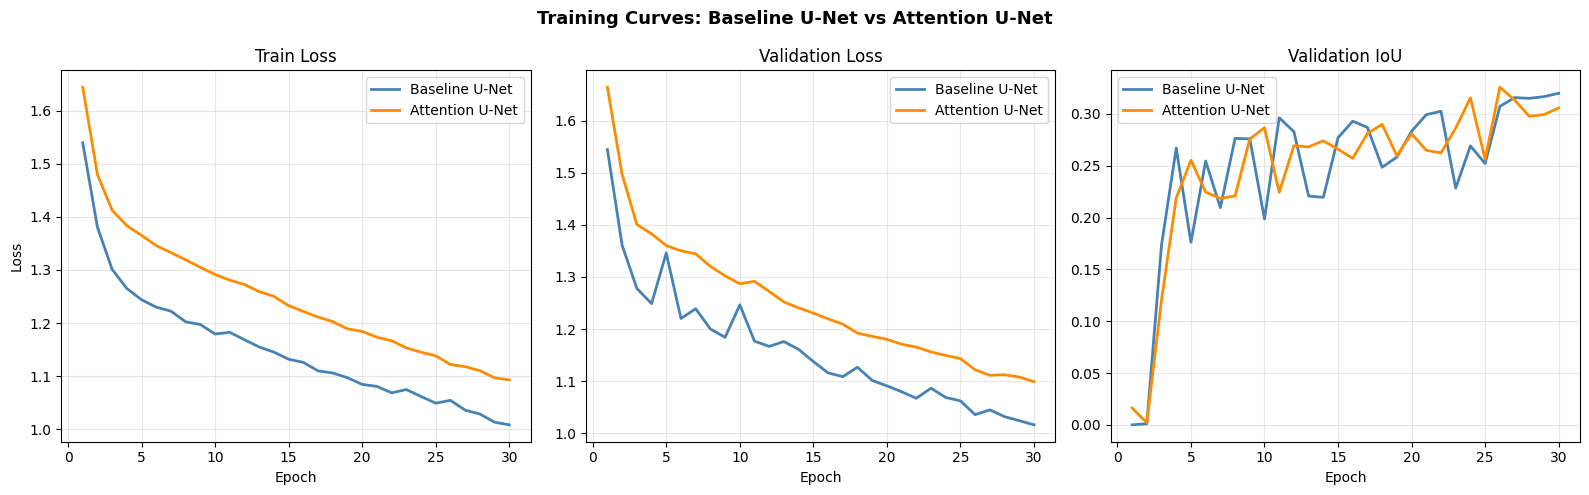

Saved: training_curves_comparison.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Train Loss
axes[0].plot(prajwal_log["epoch"], prajwal_log["train_loss"], label="Baseline U-Net",    color="steelblue",  linewidth=2)
axes[0].plot(divya_log["epoch"],   divya_log["train_loss"],   label="Attention U-Net",   color="darkorange", linewidth=2)
axes[0].set_title("Train Loss", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val Loss
axes[1].plot(prajwal_log["epoch"], prajwal_log["val_loss"], label="Baseline U-Net",    color="steelblue",  linewidth=2)
axes[1].plot(divya_log["epoch"],   divya_log["val_loss"],   label="Attention U-Net",   color="darkorange", linewidth=2)
axes[1].set_title("Validation Loss", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Val IoU
axes[2].plot(prajwal_log["epoch"], prajwal_log["val_iou"], label="Baseline U-Net",    color="steelblue",  linewidth=2)
axes[2].plot(divya_log["epoch"],   divya_log["val_iou"],   label="Attention U-Net",   color="darkorange", linewidth=2)
axes[2].set_title("Validation IoU", fontsize=12)
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle("Training Curves: Baseline U-Net vs Attention U-Net", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150)
plt.show()
print("Saved:",  "training_curves_comparison.png")

## 6. Per-Sample Metrics on Test Split
*(Uses baseline prediction masks from Saikiran's output)*

In [6]:
def to_abs(p):
    p = Path(str(p).replace("\\", "/"))
    return p if p.is_absolute() else (PROJECT_ROOT / p).resolve()


def load_mask_png(path, size=256):
    arr = np.array(Image.open(path).convert("L").resize((size, size), Image.NEAREST))
    return (arr > 127).astype(np.uint8)


df = pd.read_csv(METADATA_PATH)
test_df = df[(df["split"] == "test") & (df["mask_status"] == "OK")].reset_index(drop=True)
print(f"Test samples: {len(test_df)}")

rows = []
for _, row in test_df.iterrows():
    sid       = row["sample_id"]
    pred_path = PREDICTIONS_DIR / f"{sid}_pred.png"
    gt_path   = to_abs(row["mask_path"])

    if not pred_path.exists():
        print(f"Missing prediction: {sid}")
        continue

    pred = load_mask_png(pred_path)
    gt   = load_mask_png(gt_path)

    p_flat = pred.flatten()
    g_flat = gt.flatten()

    iou       = jaccard_score(g_flat, p_flat, zero_division=0)
    dice      = f1_score(g_flat, p_flat, zero_division=0)
    precision = precision_score(g_flat, p_flat, zero_division=0)
    recall    = recall_score(g_flat, p_flat, zero_division=0)
    accuracy  = accuracy_score(g_flat, p_flat)
    gt_flood_ratio = float(g_flat.mean())

    rows.append({
        "sample_id"     : sid,
        "iou"           : round(iou, 4),
        "dice"          : round(dice, 4),
        "precision"     : round(precision, 4),
        "recall"        : round(recall, 4),
        "accuracy"      : round(accuracy, 4),
        "gt_flood_ratio": round(gt_flood_ratio, 4),
    })

scored = pd.DataFrame(rows)
print(f"\nScored {len(scored)} test samples")
scored.to_csv(OUT_DIR / "per_sample_metrics.csv", index=False)
print("Saved:", "per_sample_metrics.csv")
print(scored.describe().round(3))

Test samples: 31

Scored 31 test samples
Saved: per_sample_metrics.csv
          iou    dice  precision  recall  accuracy  gt_flood_ratio
count  31.000  31.000     31.000  31.000    31.000          31.000
mean    0.128   0.200      0.256   0.241     0.974           0.019
std     0.146   0.215      0.253   0.287     0.044           0.033
min     0.000   0.000      0.000   0.000     0.854           0.000
25%     0.000   0.000      0.000   0.000     0.981           0.002
50%     0.090   0.165      0.241   0.115     0.995           0.004
75%     0.216   0.355      0.413   0.495     0.998           0.012
max     0.448   0.619      0.818   0.910     1.000           0.112


## 7. Failure Case Categorisation

In [7]:
IOU_GOOD      = 0.50
IOU_ACCEPT    = 0.30
PRECISION_THR = 0.35
RECALL_THR    = 0.20

def categorise(row):
    iou  = row["iou"]
    p    = row["precision"]
    r    = row["recall"]
    gt_r = row["gt_flood_ratio"]

    if gt_r < 0.01 and iou == 0:
        return "correct_empty"        # no flood, predicted none — correct
    if gt_r < 0.01 and iou > 0:
        return "false_alarm"          # no flood but model predicted flood
    if iou >= IOU_GOOD:
        return "good"                 # strong prediction
    if iou >= IOU_ACCEPT:
        return "acceptable"           # mediocre but not bad
    if r < RECALL_THR:
        return "missed_detection"     # almost no flood pixels found
    if p < PRECISION_THR and r > 0.6:
        return "over_segmentation"    # predicting too much
    if r < 0.40 and p > 0.6:
        return "under_segmentation"   # predicting too little
    return "poor"

scored["category"] = scored.apply(categorise, axis=1)

cat_counts = scored["category"].value_counts()
print("Failure category distribution:")
print(cat_counts.to_string())

Failure category distribution:
category
false_alarm          11
correct_empty        10
acceptable            5
poor                  4
over_segmentation     1


## 8. Score Distribution Plots

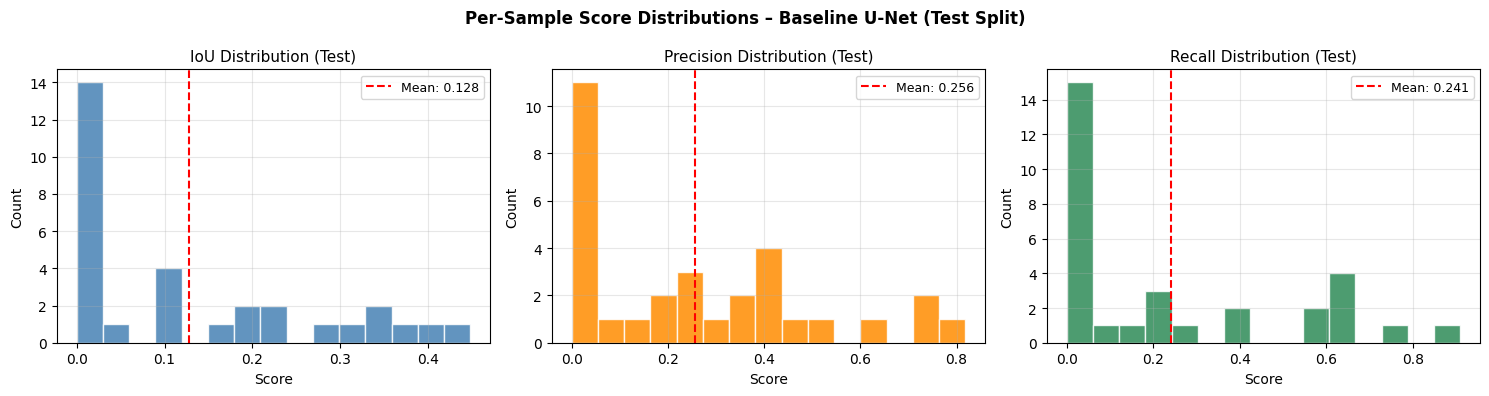

Saved: score_distributions.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color, title in [
    (axes[0], "iou",       "steelblue",  "IoU Distribution (Test)"),
    (axes[1], "precision", "darkorange", "Precision Distribution (Test)"),
    (axes[2], "recall",    "seagreen",   "Recall Distribution (Test)"),
]:
    ax.hist(scored[col], bins=15, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(scored[col].mean(), color="red", linestyle="--",
               label=f"Mean: {scored[col].mean():.3f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Per-Sample Score Distributions – Baseline U-Net (Test Split)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FAILURE_DIR / "score_distributions.png", dpi=150)
plt.show()
print("Saved:", "score_distributions.png")

## 9. Failure Category Chart

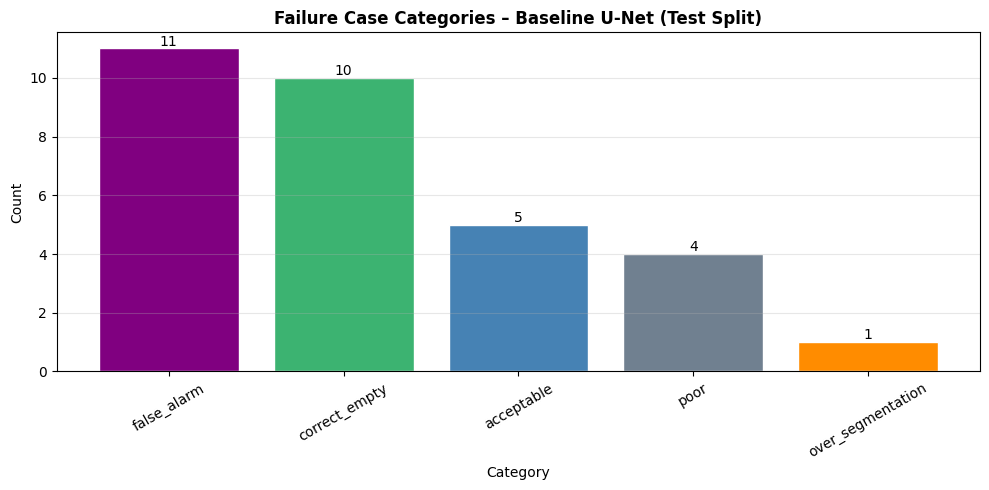

Saved: category_counts.png


In [9]:
colors = {
    "good"             : "seagreen",
    "correct_empty"    : "mediumseagreen",
    "acceptable"       : "steelblue",
    "poor"             : "slategray",
    "over_segmentation": "darkorange",
    "under_segmentation": "indianred",
    "missed_detection" : "firebrick",
    "false_alarm"      : "purple",
}

bar_colors = [colors.get(c, "gray") for c in cat_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cat_counts.index, cat_counts.values, color=bar_colors, edgecolor="white")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha="center", fontsize=10)
ax.set_title("Failure Case Categories – Baseline U-Net (Test Split)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FAILURE_DIR / "category_counts.png", dpi=150)
plt.show()
print("Saved:", "category_counts.png")

## 10. Worst Cases Visual – Lowest IoU Samples

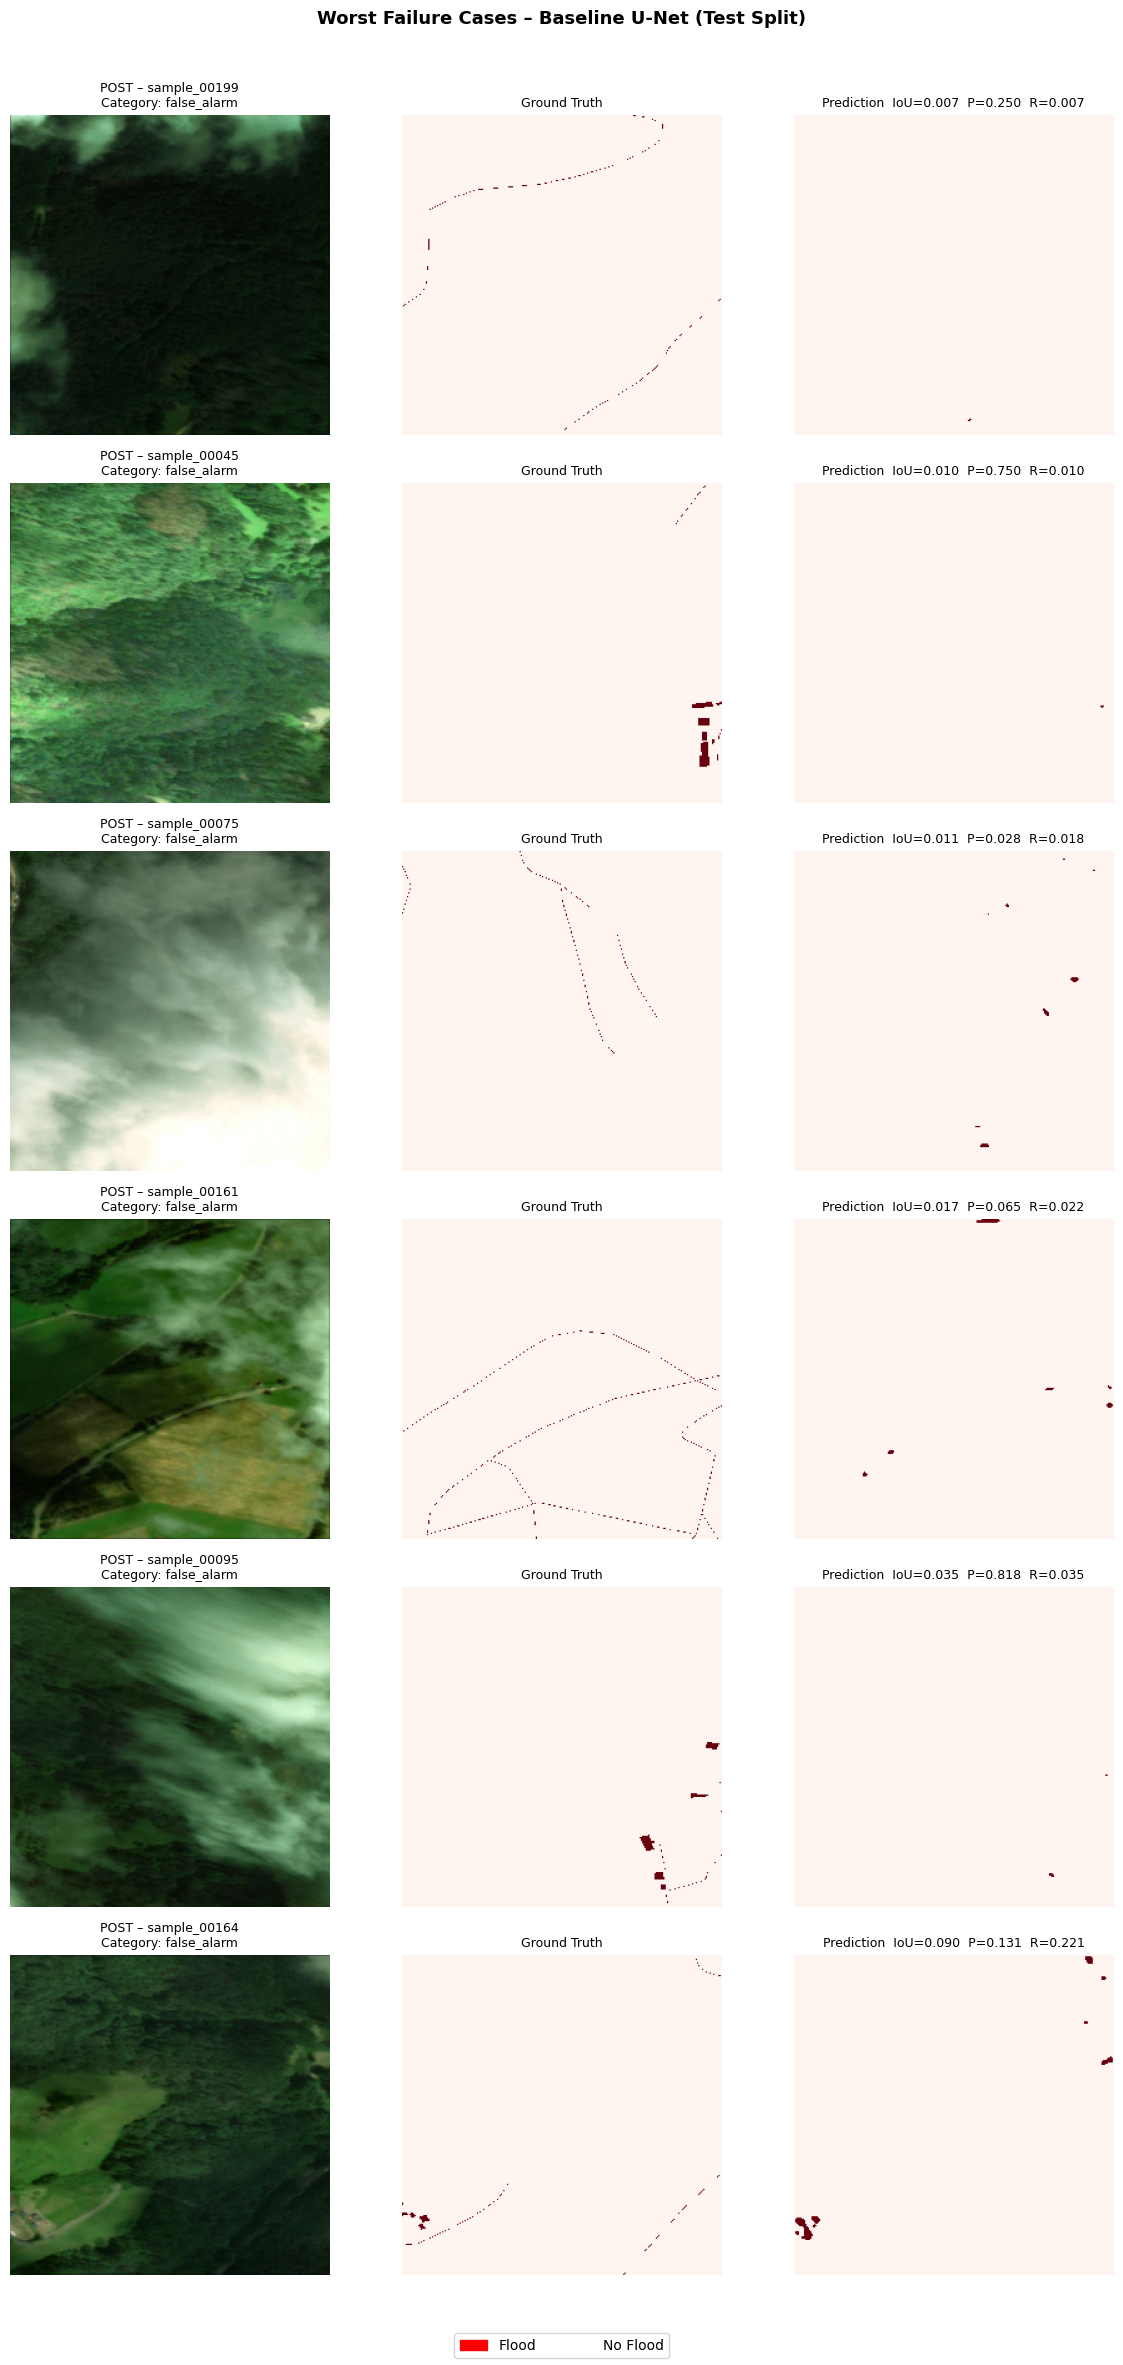

Saved: worst_cases.png


In [10]:
def load_post_tif(path, size=256):
    path = to_abs(path)
    with rasterio.open(path) as src:
        arr = src.read()
    if arr.shape[0] == 1:
        arr = np.repeat(arr, 3, axis=0)
    arr = arr[:3].astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    img = Image.fromarray((np.transpose(arr, (1,2,0)) * 255).astype(np.uint8))
    return np.array(img.resize((size, size), Image.BILINEAR)) / 255.0


worst_n = min(6, len(scored))
worst   = scored[scored["category"].isin(
    ["poor", "missed_detection", "over_segmentation", "under_segmentation", "false_alarm"]
)].sort_values("iou").head(worst_n)

if len(worst) == 0:
    worst = scored.sort_values("iou").head(worst_n)

fig, axes = plt.subplots(len(worst), 3, figsize=(12, 4 * len(worst)))
if len(worst) == 1:
    axes = [axes]

for ax_row, (_, row) in zip(axes, worst.iterrows()):
    sid  = row["sample_id"]
    meta = test_df[test_df["sample_id"] == sid].iloc[0]

    post = load_post_tif(meta["post_path"])
    gt   = load_mask_png(to_abs(meta["mask_path"]))
    pred = load_mask_png(PREDICTIONS_DIR / f"{sid}_pred.png")

    ax_row[0].imshow(np.clip(post, 0, 1))
    ax_row[0].set_title(f"POST – {sid}\nCategory: {row['category']}", fontsize=9)
    ax_row[0].axis("off")

    ax_row[1].imshow(gt, cmap="Reds", vmin=0, vmax=1)
    ax_row[1].set_title(f"Ground Truth", fontsize=9)
    ax_row[1].axis("off")

    ax_row[2].imshow(pred, cmap="Reds", vmin=0, vmax=1)
    ax_row[2].set_title(
        f"Prediction  IoU={row['iou']:.3f}  P={row['precision']:.3f}  R={row['recall']:.3f}",
        fontsize=9
    )
    ax_row[2].axis("off")

flood_patch    = mpatches.Patch(color="red",   label="Flood")
no_flood_patch = mpatches.Patch(color="white", label="No Flood", edgecolor="black")
fig.legend(handles=[flood_patch, no_flood_patch], loc="lower center", ncol=2, fontsize=10)
fig.suptitle("Worst Failure Cases – Baseline U-Net (Test Split)",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(FAILURE_DIR / "worst_cases.png", dpi=150)
plt.show()
print("Saved:",  "worst_cases.png")

## 11. IoU Scatter – Precision vs Recall

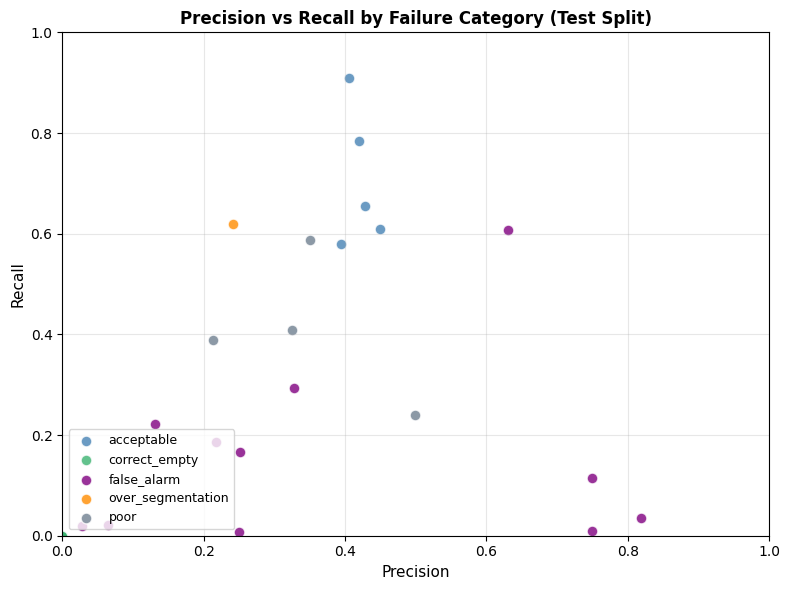

Saved: precision_recall_scatter.png


In [11]:
category_colors = {
    "good"             : "seagreen",
    "correct_empty"    : "mediumseagreen",
    "acceptable"       : "steelblue",
    "poor"             : "slategray",
    "over_segmentation": "darkorange",
    "under_segmentation": "indianred",
    "missed_detection" : "firebrick",
    "false_alarm"      : "purple",
}

fig, ax = plt.subplots(figsize=(8, 6))
for cat, grp in scored.groupby("category"):
    ax.scatter(grp["precision"], grp["recall"],
               c=category_colors.get(cat, "gray"),
               label=cat, s=60, alpha=0.8, edgecolors="white")

ax.set_xlabel("Precision", fontsize=11)
ax.set_ylabel("Recall", fontsize=11)
ax.set_title("Precision vs Recall by Failure Category (Test Split)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="lower left")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FAILURE_DIR / "precision_recall_scatter.png", dpi=150)
plt.show()
print("Saved:",  "precision_recall_scatter.png")

## 12. Auto-Generated Report Summary

In [12]:
CATEGORY_DESCRIPTIONS = {
    "correct_empty"     : "No flood in GT, model correctly predicts none (true negative scene)",
    "good"              : "IoU >= 0.50 — strong prediction",
    "acceptable"        : "IoU in [0.30, 0.50) — mediocre but reasonable",
    "poor"              : "IoU < 0.30 with no specific pattern",
    "false_alarm"       : "Model predicts flood on a clean (empty GT) scene",
    "missed_detection"  : "Model predicts almost nothing despite significant flood in GT",
    "over_segmentation" : "Prediction area much larger than GT — low precision",
    "under_segmentation": "Prediction area much smaller than GT — low recall",
}

CATEGORY_FIXES = {
    "false_alarm"       : "Add more clean-scene training examples; raise decision threshold; use difference channel.",
    "missed_detection"  : "Address class imbalance with focal/Tversky loss; oversample flooded scenes.",
    "over_segmentation" : "Raise decision threshold; stronger regularisation; add NDWI water index channel.",
    "under_segmentation": "Lower decision threshold; multi-scale features; recall-weighted loss.",
    "poor"              : "Mix of the above — inspect qualitatively.",
    "acceptable"        : "Incremental gains from better augmentation or longer training.",
    "good"              : "No action needed.",
    "correct_empty"     : "No action needed.",
}

total = len(scored)
lines = []
lines.append("# Comparison and Error Analysis — Auto-Generated Summary\n")
lines.append("_Comparison and error analysis by Reginald. Baseline trained by Prajwal, evaluated by Saikiran. Improved model by Divya._\n")

lines.append("## Model Comparison\n")
lines.append("| Metric | Baseline (Val) | Baseline (Test) | Attention U-Net (Val) | Change |")
lines.append("|--------|---------------|----------------|----------------------|--------|")
for _, row in final_table.iterrows():
    change = f"+{row['Change (Val)']:.4f}" if row['Change (Val)'] > 0 else f"{row['Change (Val)']:.4f}"
    lines.append(
        f"| {row['Metric']} | {row['Baseline – Val']:.4f} | {row['Baseline – Test']:.4f} | "
        f"{row['Attention U-Net – Val']:.4f} | {change} |"
    )
lines.append("")

lines.append("## Analysis\n")
lines.append(
    f"The Attention U-Net improved **Recall** from {baseline_val['Recall']:.4f} to "
    f"{improved_val['Recall']:.4f} (+{improved_val['Recall']-baseline_val['Recall']:.4f}), "
    f"indicating it detects more flood pixels. However, **IoU** decreased slightly from "
    f"{baseline_val['IoU']:.4f} to {improved_val['IoU']:.4f}, suggesting the attention "
    f"mechanism increases sensitivity at the cost of some precision on this small dataset (141 train samples).\n"
)

lines.append("## Failure Case Analysis (Baseline, Test Split)\n")
lines.append(f"Total test samples scored: **{total}**\n")
lines.append("| Category | Count | Share | Description |")
lines.append("|----------|-------|-------|-------------|")
for cat, count in cat_counts.items():
    desc = CATEGORY_DESCRIPTIONS.get(cat, "")
    lines.append(f"| `{cat}` | {count} | {count/total:.0%} | {desc} |")
lines.append("")

lines.append("## Top Failure Modes and Suggested Fixes\n")
top_failures = [c for c in cat_counts.index if c not in ("good", "correct_empty", "acceptable")][:3]
for i, cat in enumerate(top_failures, 1):
    lines.append(f"{i}. **{cat}** — {CATEGORY_FIXES.get(cat, '')}")
lines.append("")

lines.append("## Visuals\n")
lines.append("- `final_comparison_chart.png` — metric bar chart across all models")
lines.append("- `training_curves_comparison.png` — loss and IoU curves")
lines.append("- `failure_analysis/score_distributions.png` — IoU/precision/recall histograms")
lines.append("- `failure_analysis/category_counts.png` — failure category bar chart")
lines.append("- `failure_analysis/worst_cases.png` — worst prediction examples")
lines.append("- `failure_analysis/precision_recall_scatter.png` — P vs R coloured by category")

(FAILURE_DIR / "summary.md").write_text("\n".join(lines))
print("Summary written to:", "summary.md")
print("\n" + "\n".join(lines[:40]))

Summary written to: summary.md

# Comparison and Error Analysis — Auto-Generated Summary

_Comparison and error analysis by Reginald. Baseline trained by Prajwal, evaluated by Saikiran. Improved model by Divya._

## Model Comparison

| Metric | Baseline (Val) | Baseline (Test) | Attention U-Net (Val) | Change |
|--------|---------------|----------------|----------------------|--------|
| IoU | 0.3258 | 0.3138 | 0.3123 | -0.0135 |
| Dice/F1 | 0.4915 | 0.4777 | 0.4759 | -0.0156 |
| Precision | 0.3842 | 0.3867 | 0.3579 | -0.0263 |
| Recall | 0.6818 | 0.6246 | 0.7101 | +0.0283 |
| Accuracy | 0.9825 | 0.9740 | 0.9806 | -0.0019 |

## Analysis

The Attention U-Net improved **Recall** from 0.6818 to 0.7101 (+0.0283), indicating it detects more flood pixels. However, **IoU** decreased slightly from 0.3258 to 0.3123, suggesting the attention mechanism increases sensitivity at the cost of some precision on this small dataset (141 train samples).

## Failure Case Analysis (Baseline, Test Split)

T

## 13. Final Summary

In [13]:
print("=" * 60)
print(" COMPARISON AND ERROR ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nTest samples scored  : {len(scored)}")
print(f"Mean test IoU        : {scored['iou'].mean():.4f}")
print(f"Mean test Precision  : {scored['precision'].mean():.4f}")
print(f"Mean test Recall     : {scored['recall'].mean():.4f}")
print()
print("Failure categories:")
for cat, count in cat_counts.items():
    print(f"  {cat:<22}: {count} ({count/total:.0%})")
print()
print("Key finding:")
print(f"  Attention U-Net improves Recall by "
      f"+{improved_val['Recall']-baseline_val['Recall']:.4f} but IoU drops by "
      f"{improved_val['IoU']-baseline_val['IoU']:.4f}.")
print(f"  The dominant failure mode is '{cat_counts.index[0]}' "
      f"— see failure_analysis/summary.md for fixes.")
print()
print("Outputs saved to: outputs/reginald/")
print("  - final_comparison_table.csv")
print("  - final_comparison_chart.png")
print("  - training_curves_comparison.png")
print("  - per_sample_metrics.csv")
print("  - failure_analysis/score_distributions.png")
print("  - failure_analysis/category_counts.png")
print("  - failure_analysis/worst_cases.png")
print("  - failure_analysis/precision_recall_scatter.png")
print("  - failure_analysis/summary.md")

 COMPARISON AND ERROR ANALYSIS SUMMARY

Test samples scored  : 31
Mean test IoU        : 0.1281
Mean test Precision  : 0.2564
Mean test Recall     : 0.2409

Failure categories:
  false_alarm           : 11 (35%)
  correct_empty         : 10 (32%)
  acceptable            : 5 (16%)
  poor                  : 4 (13%)
  over_segmentation     : 1 (3%)

Key finding:
  Attention U-Net improves Recall by +0.0283 but IoU drops by -0.0135.
  The dominant failure mode is 'false_alarm' — see failure_analysis/summary.md for fixes.

Outputs saved to: outputs/reginald/
  - final_comparison_table.csv
  - final_comparison_chart.png
  - training_curves_comparison.png
  - per_sample_metrics.csv
  - failure_analysis/score_distributions.png
  - failure_analysis/category_counts.png
  - failure_analysis/worst_cases.png
  - failure_analysis/precision_recall_scatter.png
  - failure_analysis/summary.md


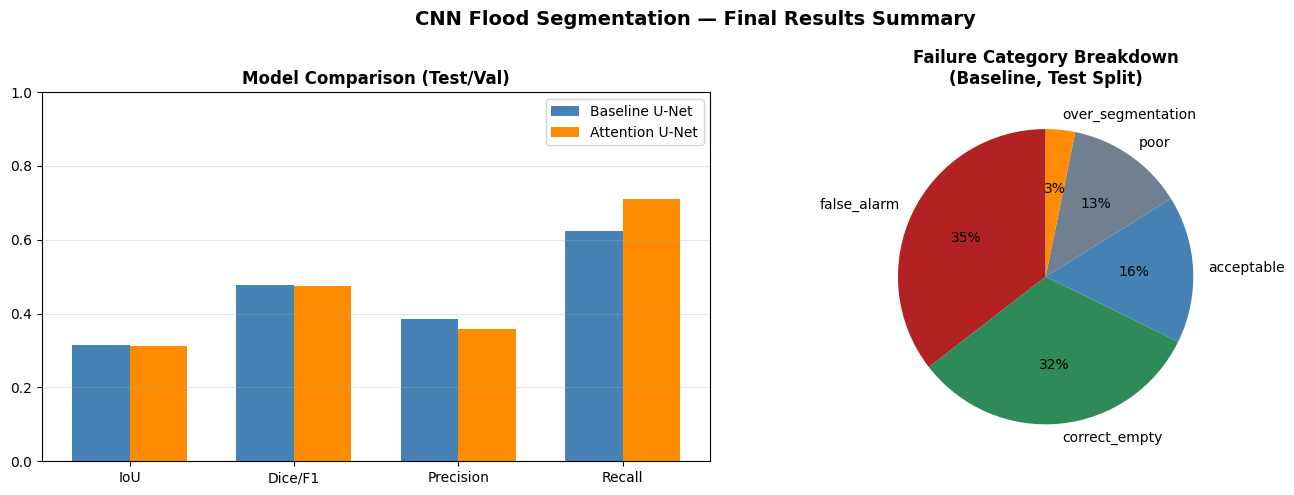

Saved: presentation_summary.png


In [14]:
# Presentation summary figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — metric comparison
metrics = ["IoU", "Dice/F1", "Precision", "Recall"]
baseline_vals  = [0.3138, 0.4777, 0.3867, 0.6246]
improved_vals  = [0.3123, 0.4759, 0.3579, 0.7101]
x = np.arange(len(metrics))
width = 0.35
axes[0].bar(x - width/2, baseline_vals,  width, label="Baseline U-Net",   color="steelblue")
axes[0].bar(x + width/2, improved_vals,  width, label="Attention U-Net",  color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Model Comparison (Test/Val)", fontweight="bold")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Right — failure breakdown pie
cat_counts.plot.pie(ax=axes[1], autopct="%1.0f%%",
                    colors=["firebrick","seagreen","steelblue","slategray","darkorange"],
                    startangle=90)
axes[1].set_ylabel("")
axes[1].set_title("Failure Category Breakdown\n(Baseline, Test Split)", fontweight="bold")

plt.suptitle("CNN Flood Segmentation — Final Results Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "presentation_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: presentation_summary.png")

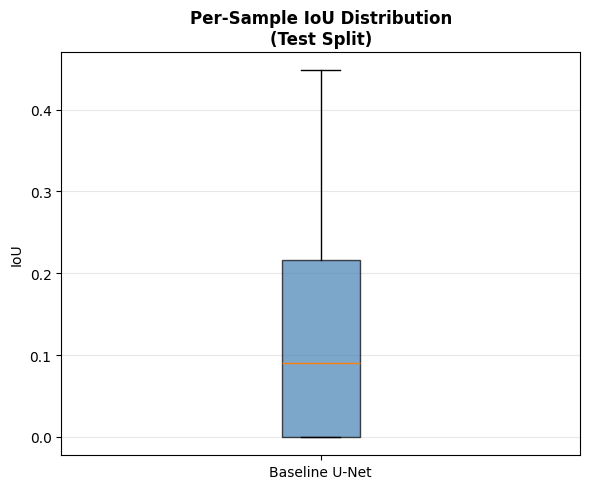

Saved: iou_boxplot.png


In [15]:
# Box plot — per-sample IoU distribution
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(scored["iou"], patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.7))
ax.set_xticklabels(["Baseline U-Net"])
ax.set_ylabel("IoU")
ax.set_title("Per-Sample IoU Distribution\n(Test Split)", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "iou_boxplot.png", dpi=150)
plt.show()
print("Saved: iou_boxplot.png")